In [1]:
import numpy as np
import pandas as pd
from scipy import interp
from sklearn.datasets import make_blobs
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[1] Используя make_blobs с любым random_state, сгенерировать датасет df1, в
котором есть три класса с размером каждого класса 1000 и четыре
количественных (недискретных) признака.

In [2]:
n_samples = 3000
n_features = 4 
n_classes = 3   

X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_classes, random_state=1)

df1 = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])
df1['target'] = y

[2] Не забываем повторять шаги с задания 1
- ключевые характеристики датасета
- корреляции
- визуализация на всех парах переменных

In [3]:
correlation_matrix = df1.corr()
print("Матрица корреляций:\n")
print(correlation_matrix)

Матрица корреляций:

           feature_1  feature_2  feature_3  feature_4    target
feature_1   1.000000   0.881259   0.008141   0.322505 -0.055560
feature_2   0.881259   1.000000  -0.203290   0.137421 -0.274414
feature_3   0.008141  -0.203290   1.000000   0.861266  0.958872
feature_4   0.322505   0.137421   0.861266   1.000000  0.873035
target     -0.055560  -0.274414   0.958872   0.873035  1.000000


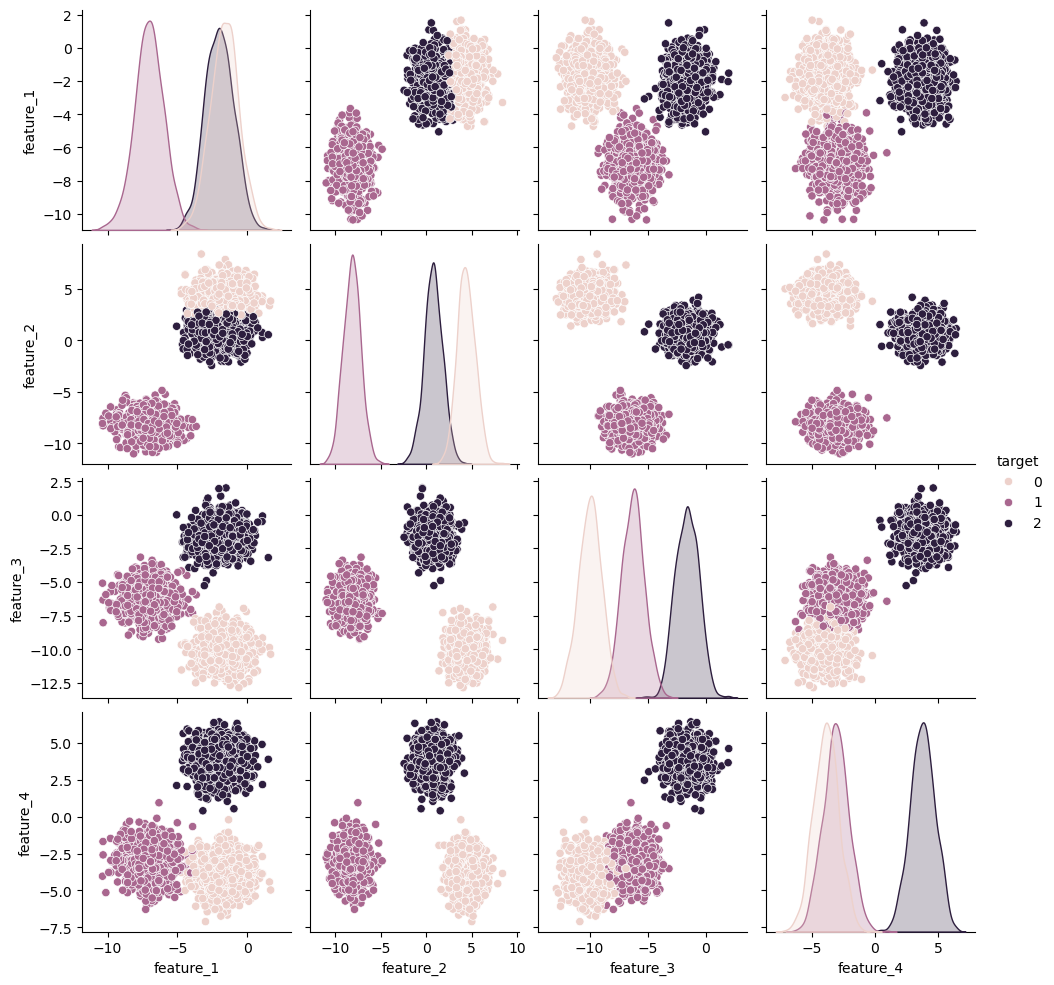

In [4]:
sns.pairplot(df1, hue='target', diag_kind='kde')
plt.show()

[3] На основе созданного в пункте [1] датасета сгенерировать отдельные
дополнительные датасеты (df2, df5, df10…), в которых объекты одного класса
повторены 2 раза, 5 раз, 10 раз, 20 раз, 50 раз, 100 раз, 1000 раз, 10k раз, а
количество объектов в остальных классов неизменно.

In [5]:
class_to_repeat = 0

counts = [1, 2, 5, 10, 20, 50, 100, 1000, 10000]

datasets = {}

for count in counts:
    df_repeated = df1[df1['target'] != class_to_repeat].copy()
    df_class_to_repeat = df1[df1['target'] == class_to_repeat].copy()
    df_class_to_repeat_repeated = pd.concat([df_class_to_repeat] * count, ignore_index=True)
    df_repeated = pd.concat([df_repeated, df_class_to_repeat_repeated], ignore_index=True)
    datasets[f'df{count}'] = df_repeated

[4] Выбрать пару классов (включая класс с повторенными объектами) и пару
количественных признаков.
Используя метод LDA (линейный дискриминантный анализ), для каждого из
датасетов df1, df2, df5, df10, df20, df50, df100, df1000, df10k, построить решающую
функцию алгоритма, разграниченные решающей функцией зоны и отдельные
объекты классов.

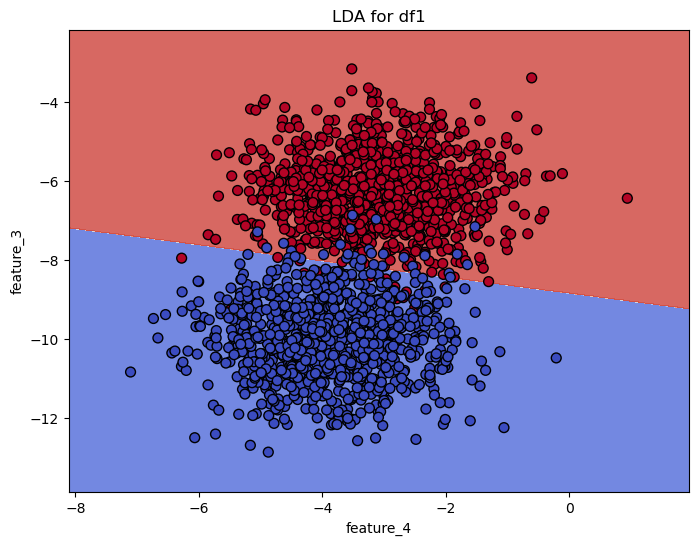

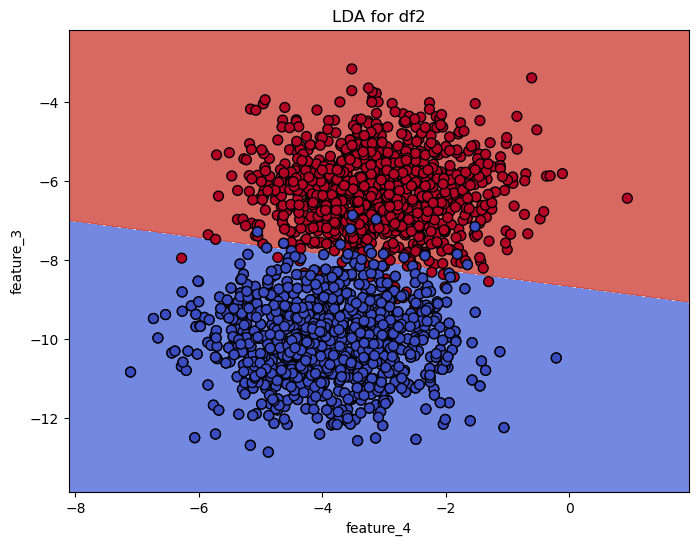

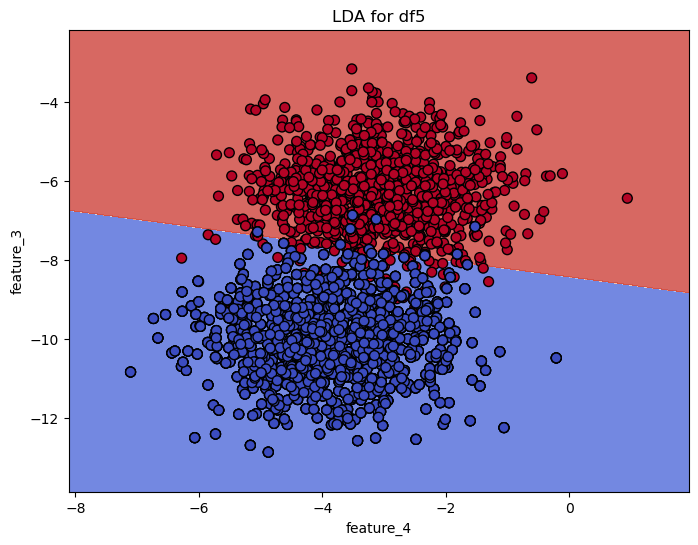

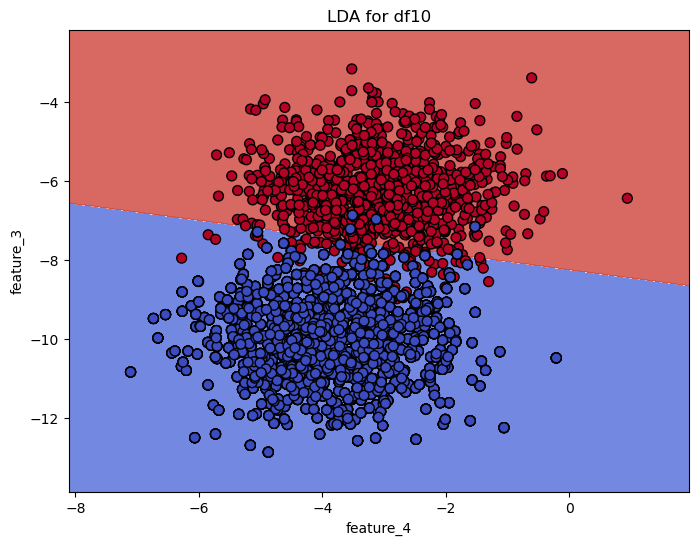

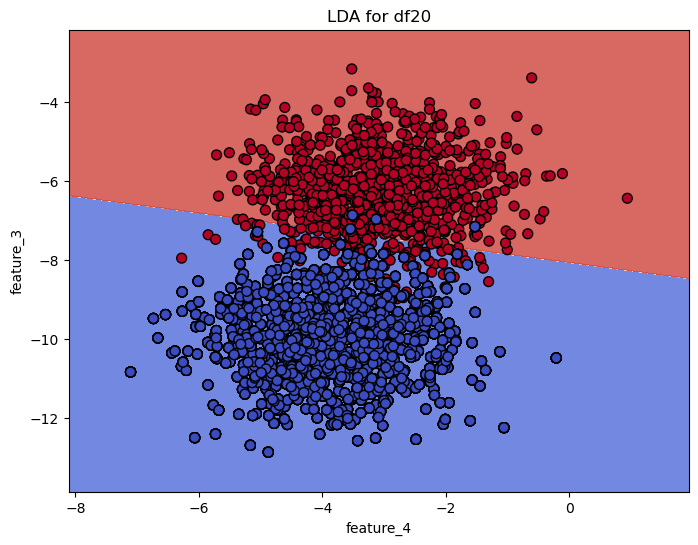

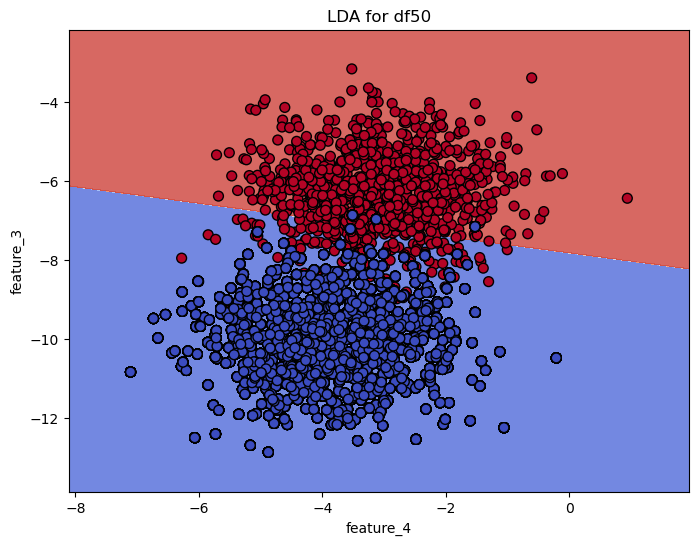

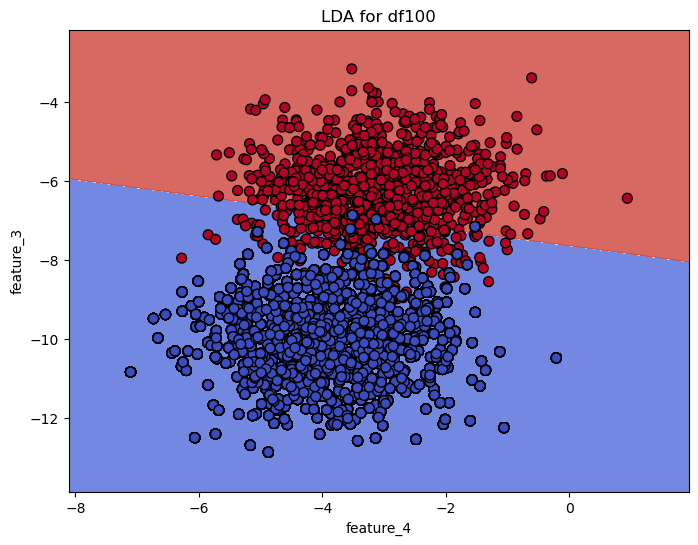

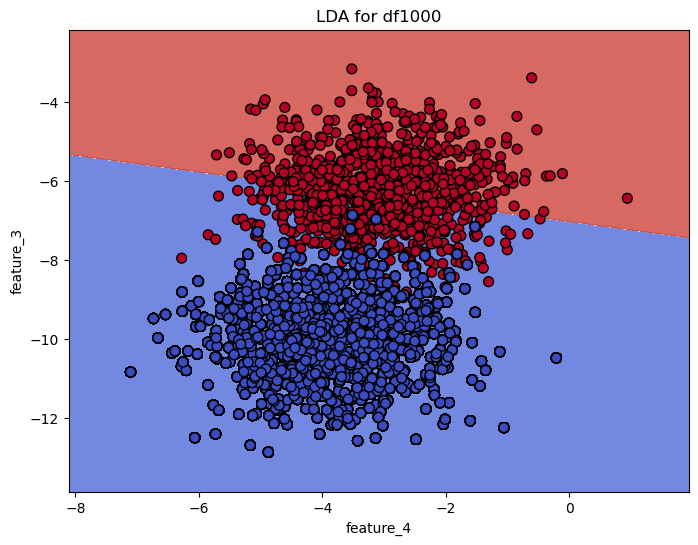

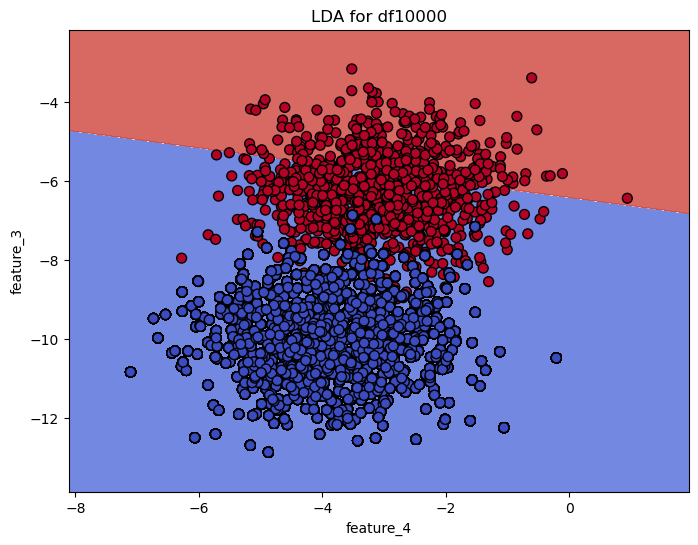

In [6]:
class1 = 0
class2 = 1
feature1 = 'feature_4'
feature2 = 'feature_3'

def plot_lda(df, class1, class2, feature1, feature2, title):
    df_selected = df[(df['target'] == class1) | (df['target'] == class2)]
    X = df_selected[[feature1, feature2]].values
    y = df_selected['target'].values 

    lda = LinearDiscriminantAnalysis()
    lda.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50, cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()

for name, df in datasets.items():
    plot_lda(df, class1, class2, feature1, feature2, title=f'LDA for {name}')


[5] Повторить пункт [4] для алгоритма SVM.

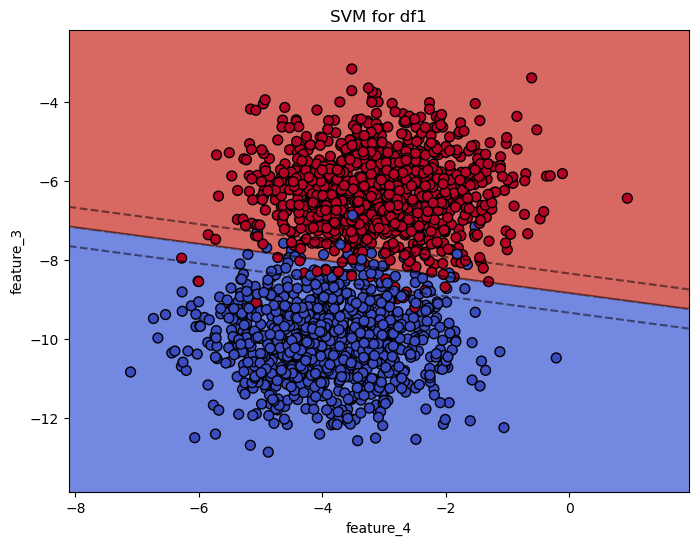

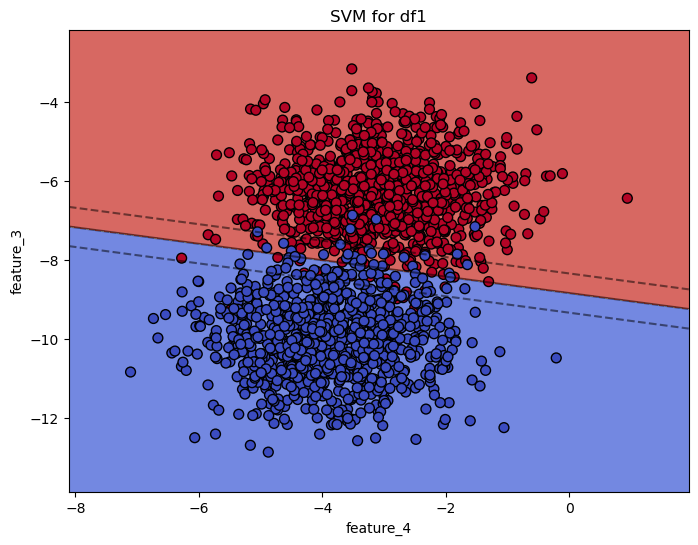

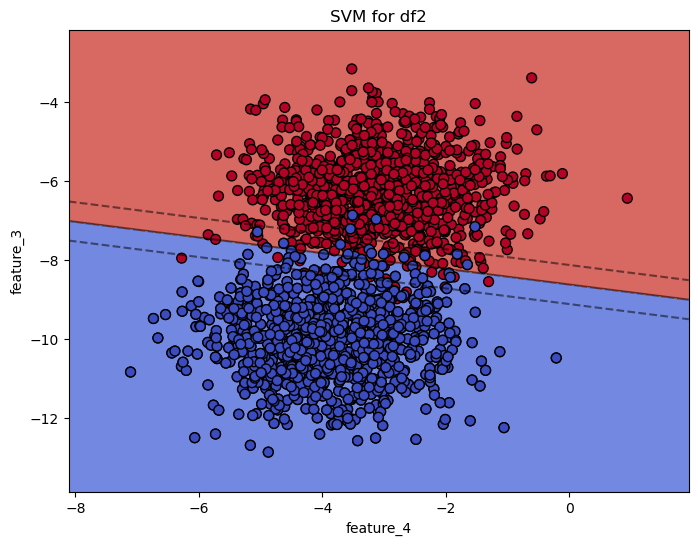

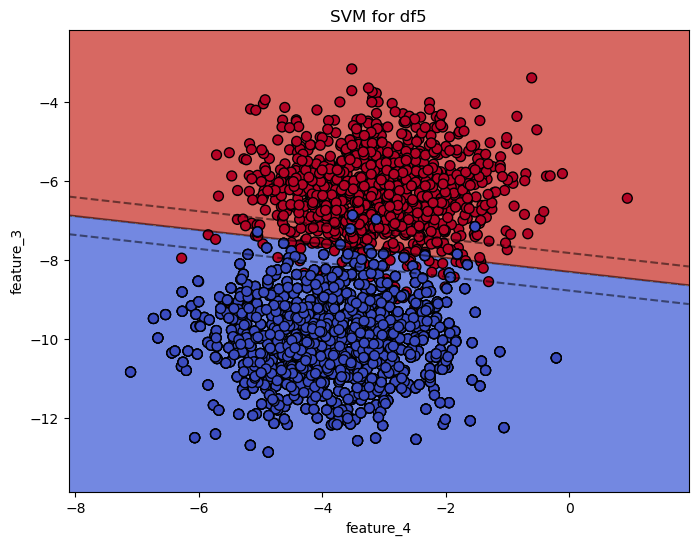

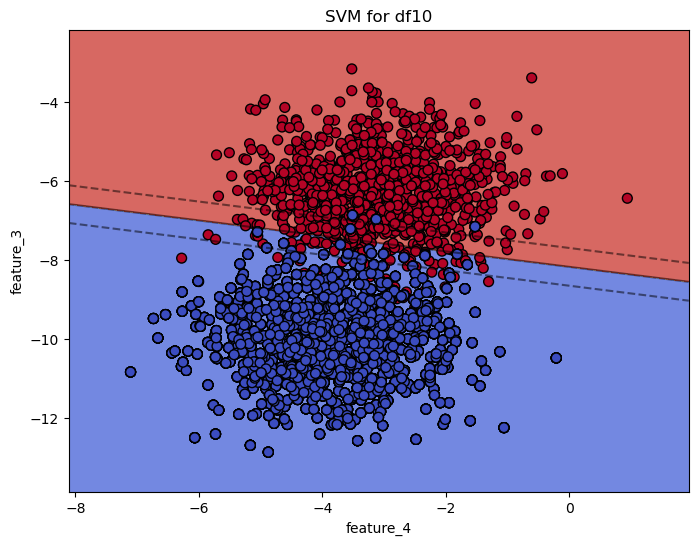

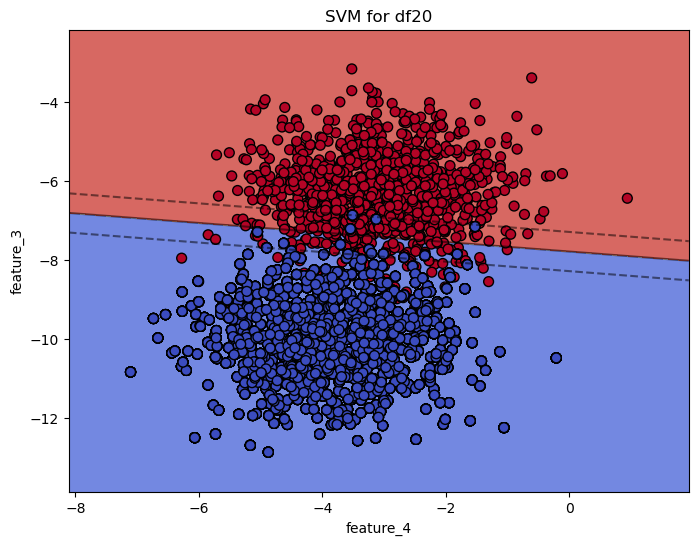

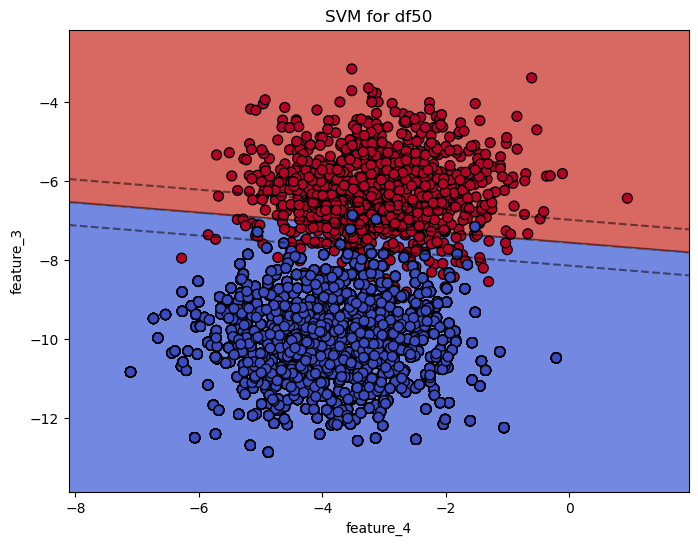

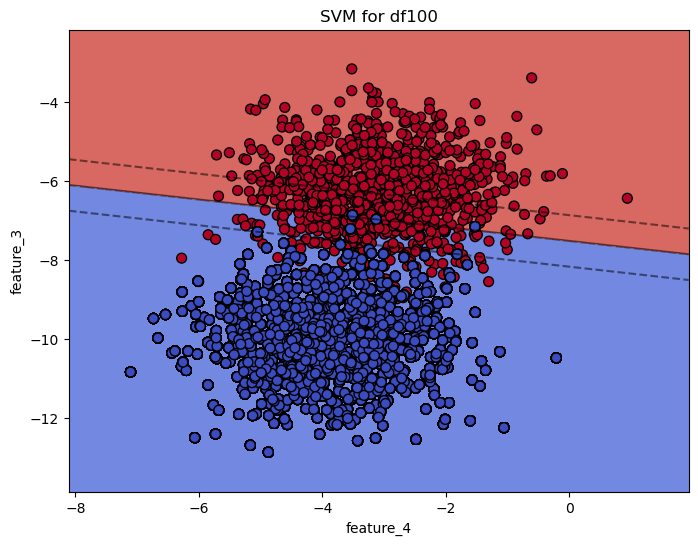

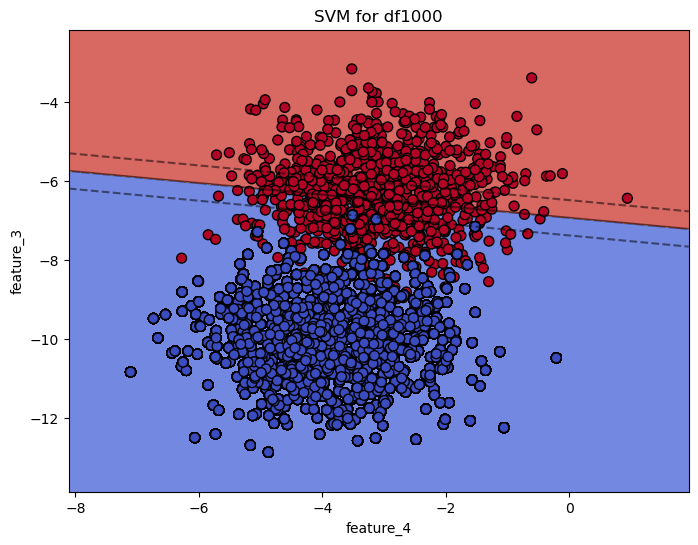

In [23]:
class1 = 0
class2 = 1
feature1 = 'feature_4'
feature2 = 'feature_3'

def plot_svm(df, class1, class2, feature1, feature2, title):
    df_selected = df[(df['target'] == class1) | (df['target'] == class2)]
    X = df_selected[[feature1, feature2]].values
    y = df_selected['target'].values

    svm = SVC(kernel='linear', C=0.2)
    svm.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50, cmap=plt.cm.coolwarm)
    
    Z_decision = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z_decision = Z_decision.reshape(xx.shape)
    plt.contour(xx, yy, Z_decision, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    plt.title(title)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()

plot_svm(df1, class1, class2, feature1, feature2, title=f'SVM for df1')
for name, df in datasets.items():
    plot_svm(df, class1, class2, feature1, feature2, title=f'SVM for {name}')

[6] Для каждого из датасетов df1, df2, df5, df10, df20, df50, df100, df1000, df10k из
пункта [4] восстановить в таблицу координаты следующих точек:
- центр отрезка, соединяющего центры масс выбранных классов
- общий центр масс выбранных классов
- точку пересечения решающей функции и отрезка, соединяющего центры масс
выбранных классов.
В виде графиков визуализировать зависимости между количеством повторов в
классе с повторенными объектами и координатами найденных точек.

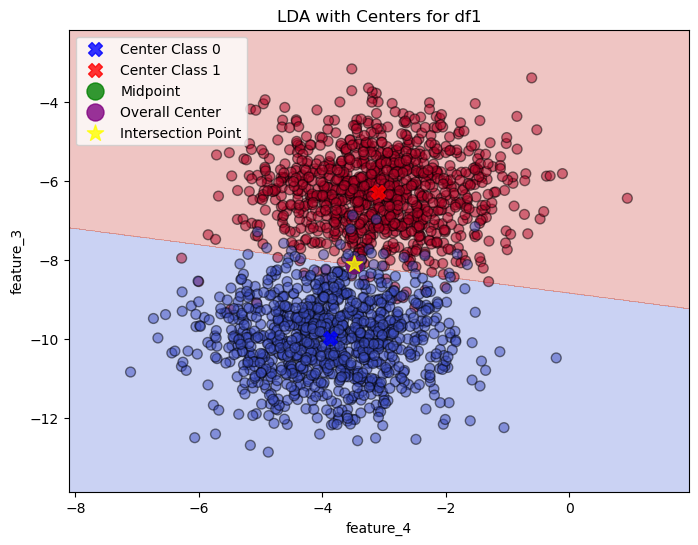

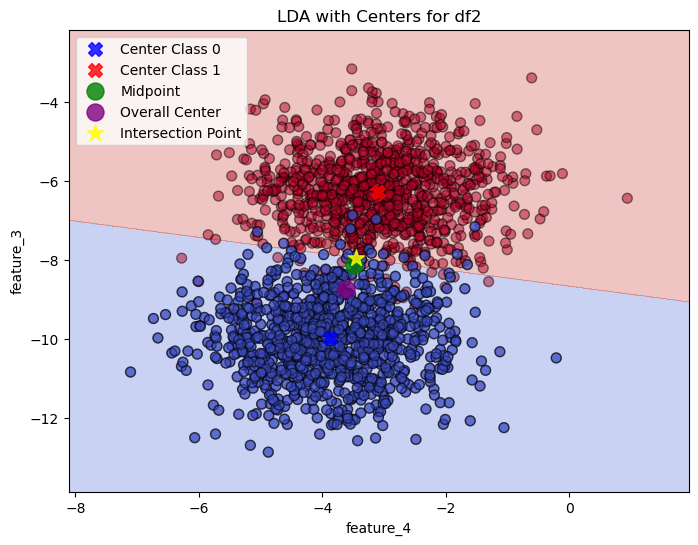

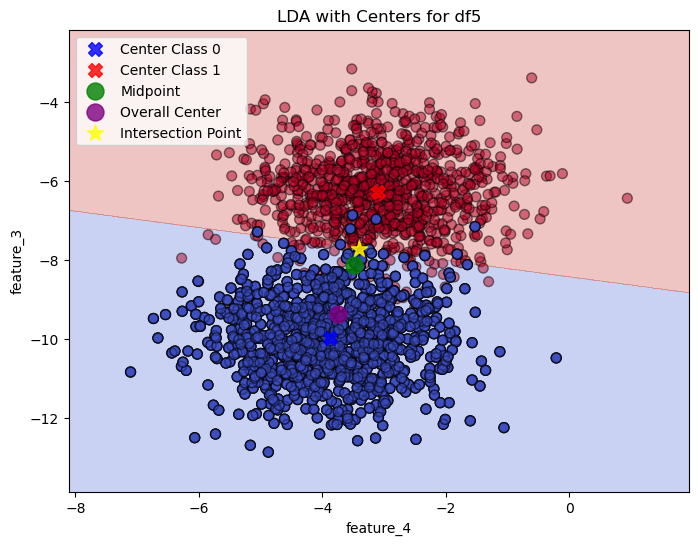

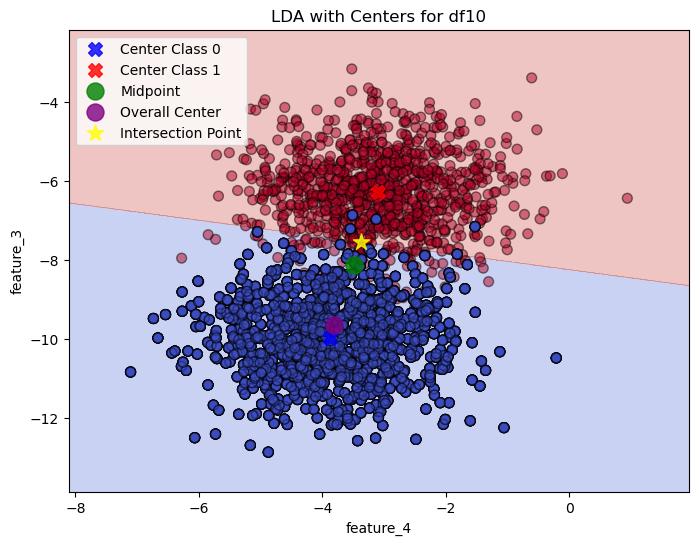

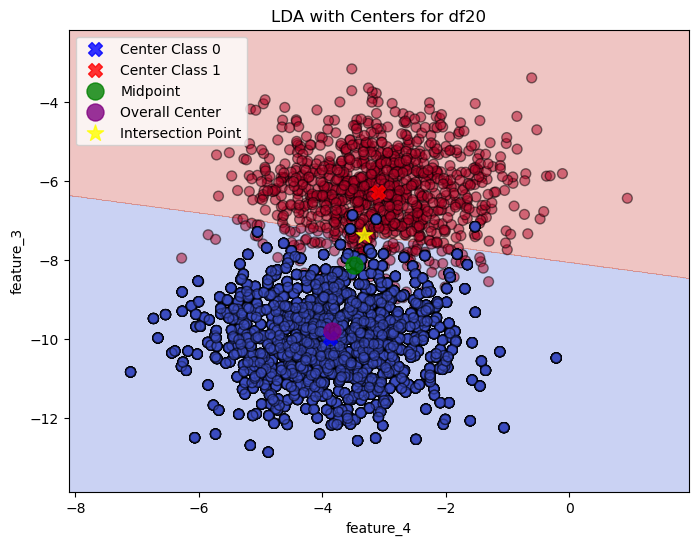

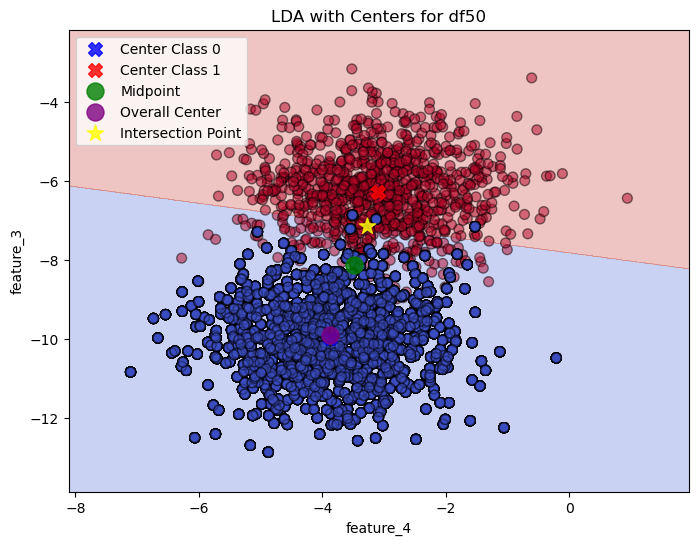

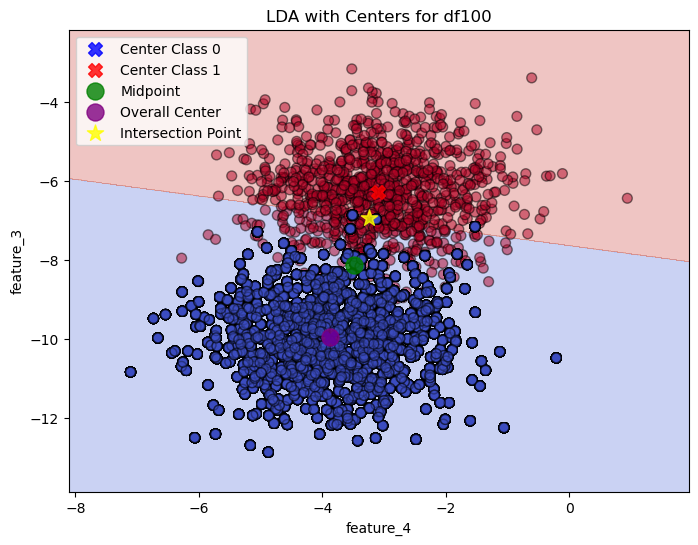

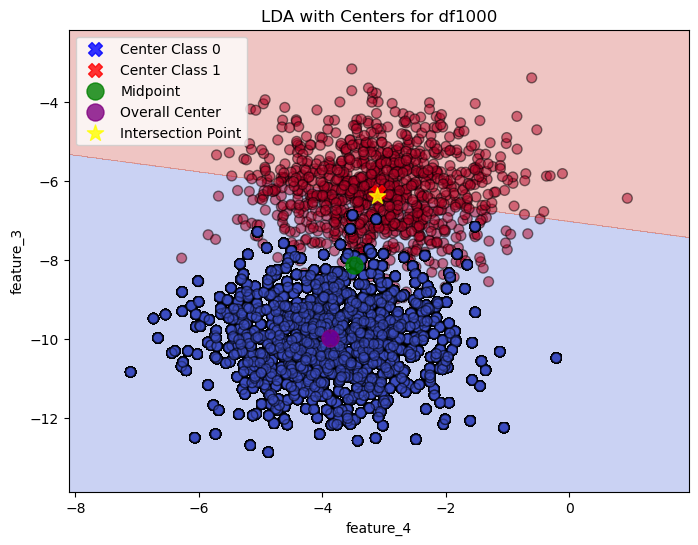

In [ ]:
def get_centers_and_intersection(df, class1, class2, feature1, feature2):
    subset = df[df['target'].isin([class1, class2])]
    center_class1 = subset[subset['target'] == class1][[feature1, feature2]].mean()
    center_class2 = subset[subset['target'] == class2][[feature1, feature2]].mean()
    
    mid_point = (center_class1 + center_class2) / 2
    overall_center = subset[[feature1, feature2]].mean()
    
    X = subset[[feature1, feature2]].values
    y = subset['target'].values
    lda = LinearDiscriminantAnalysis()
    lda.fit(X, y)
    
    line_points = np.linspace(center_class1, center_class2, 100)
    
    Z_decision = lda.decision_function(line_points)
    intersection_point = line_points[np.argmin(np.abs(Z_decision))]
    
    return center_class1, center_class2, mid_point, overall_center, intersection_point

def plot_lda_with_centers(df, class1, class2, feature1, feature2, title):
    center_class1, center_class2, mid_point, overall_center, intersection_point = get_centers_and_intersection(df, class1, class2, feature1, feature2)

    df_selected = df[(df['target'] == class1) | (df['target'] == class2)]
    X = df_selected[[feature1, feature2]].values
    y = df_selected['target'].values

    lda = LinearDiscriminantAnalysis()
    lda.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50, cmap=plt.cm.coolwarm, alpha=0.5)
    
    plt.scatter(center_class1[feature1], center_class1[feature2], c='blue', s=100, marker='X', label=f'Center Class {class1}', alpha=0.8)
    plt.scatter(center_class2[feature1], center_class2[feature2], c='red', s=100, marker='X', label=f'Center Class {class2}', alpha=0.8)
    plt.scatter(mid_point[feature1], mid_point[feature2], c='green', s=150, marker='o', label='Midpoint', alpha=0.8)
    plt.scatter(overall_center[feature1], overall_center[feature2], c='purple', s=150, marker='o', label='Overall Center', alpha=0.8)
    plt.scatter(intersection_point[0], intersection_point[1], c='yellow', s=150, marker='*', label='Intersection Point', alpha=0.8)

    plt.title(title)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.legend()
    plt.show()

for name, df in datasets.items():
    plot_lda_with_centers(df, class1, class2, feature1, feature2, title=f'LDA with Centers for {name}')


[7] Выбрать целевой класс для решений из пункта [4].
Для каждого из решений из пункта [4]:
- Построить ROC кривую и рассчитать метрику AUROC.
- Построить PR кривую и рассчитать метрику AUPRC.
- (*) Построить PRgain кривую и рассчитать метрику AUPRgainC.

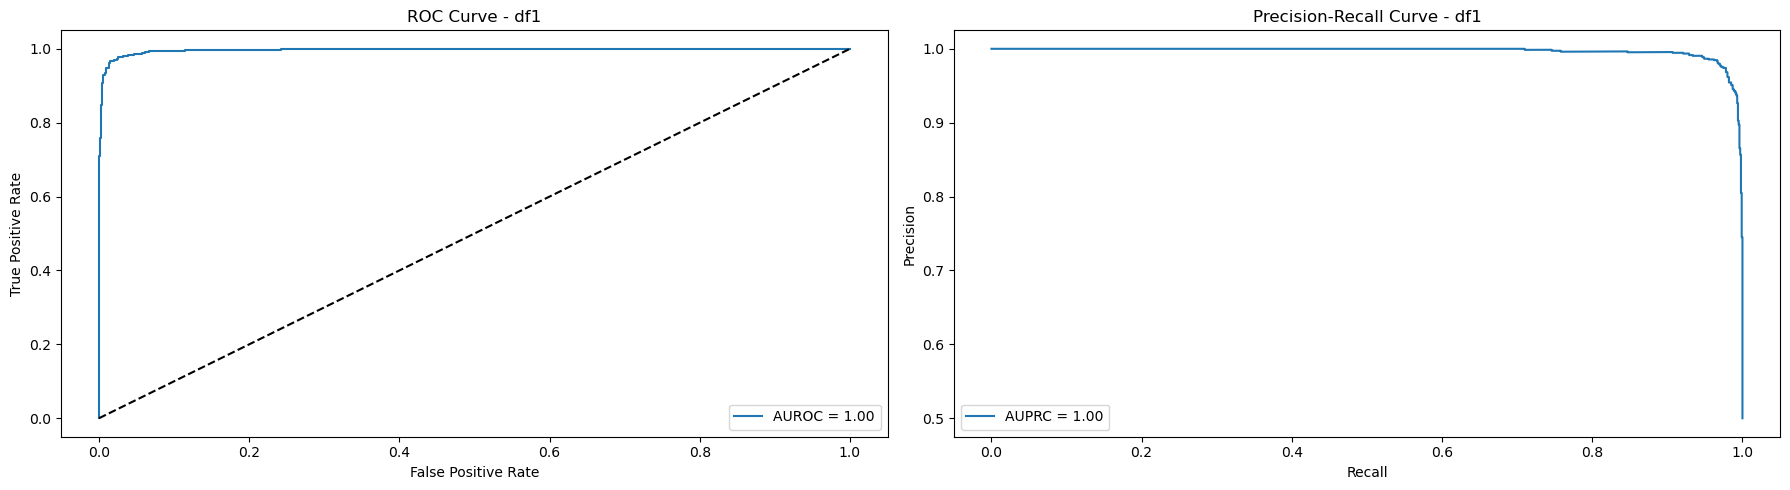

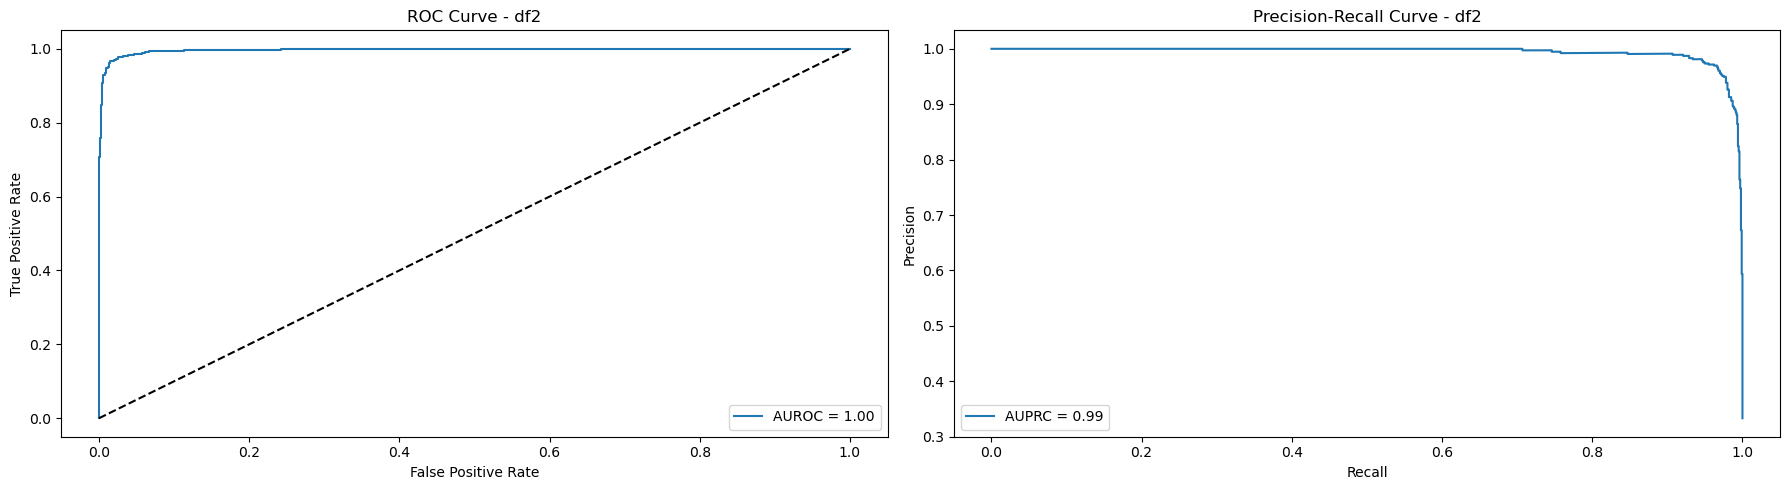

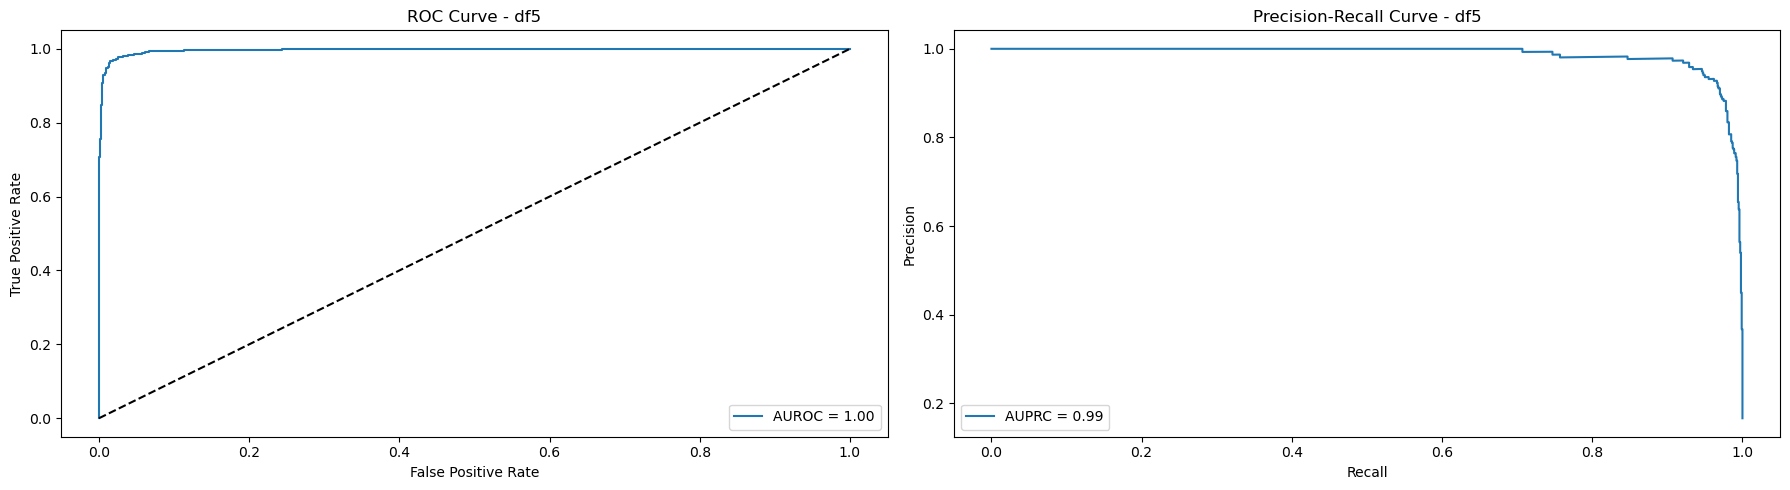

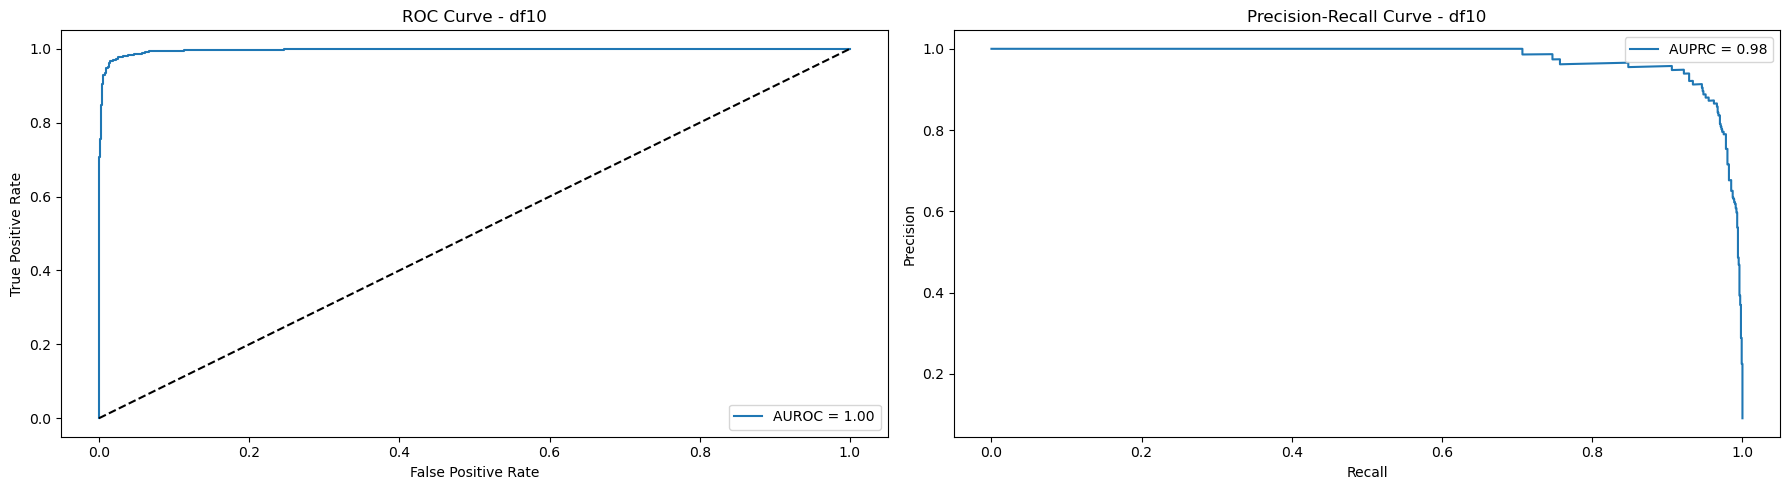

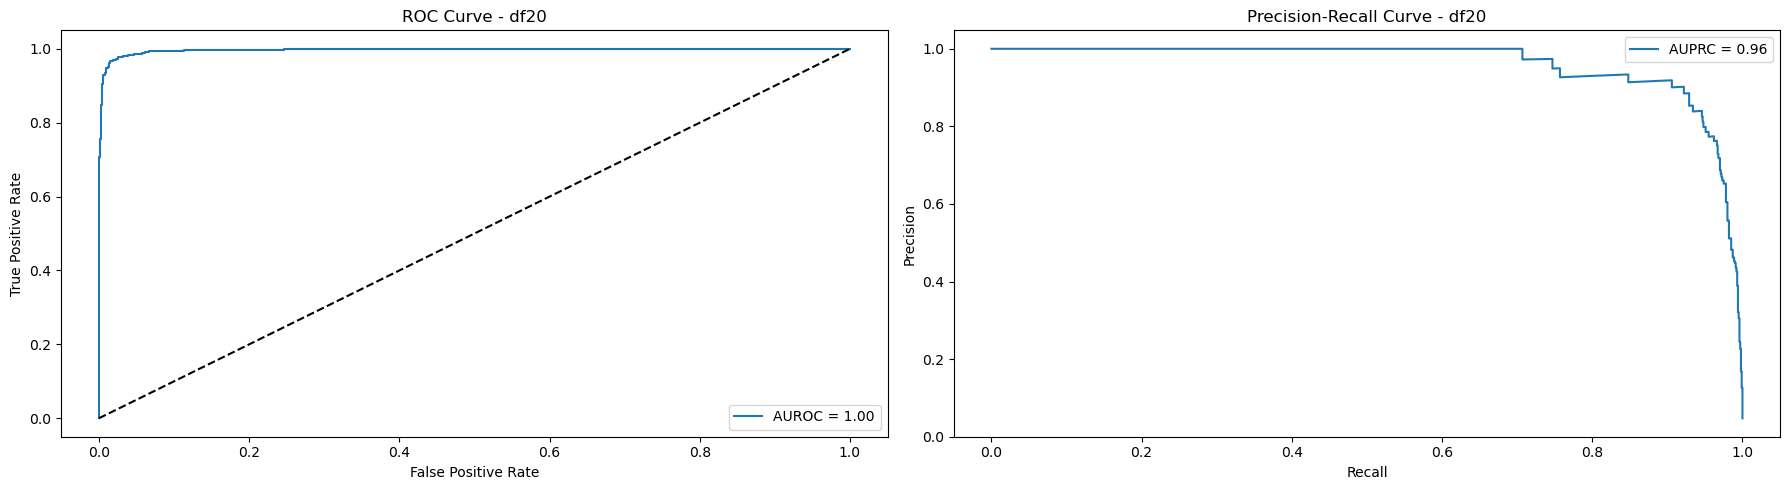

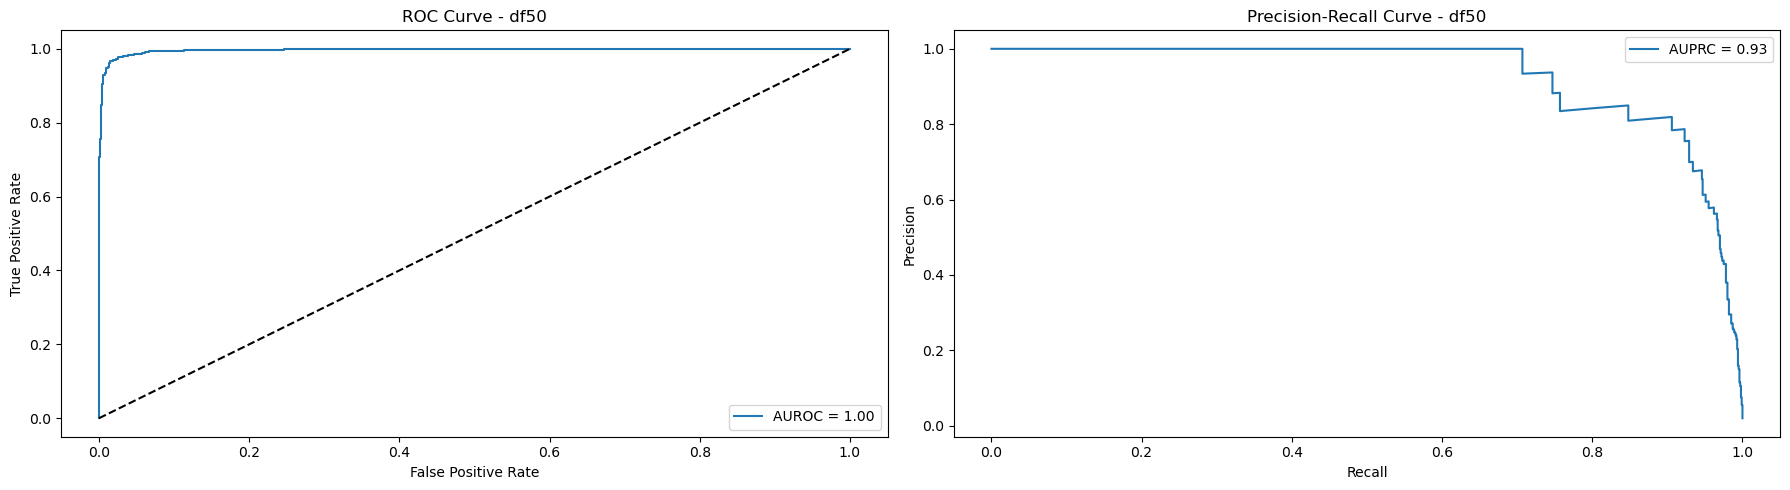

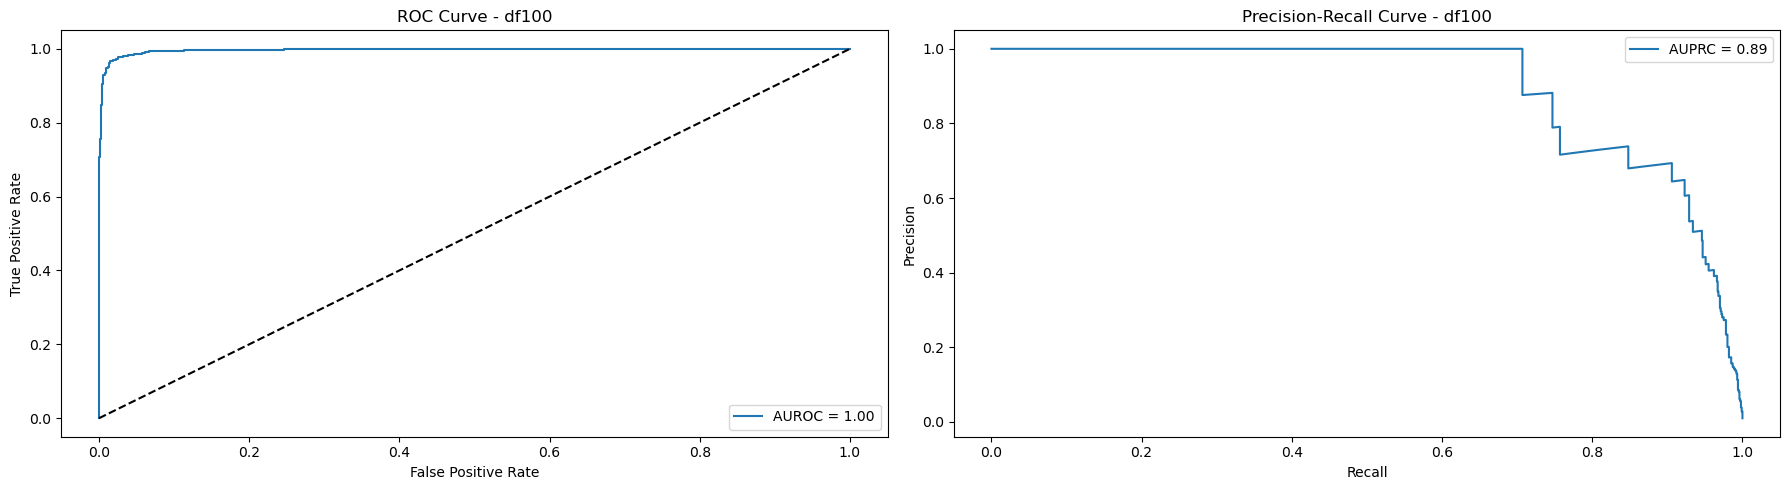

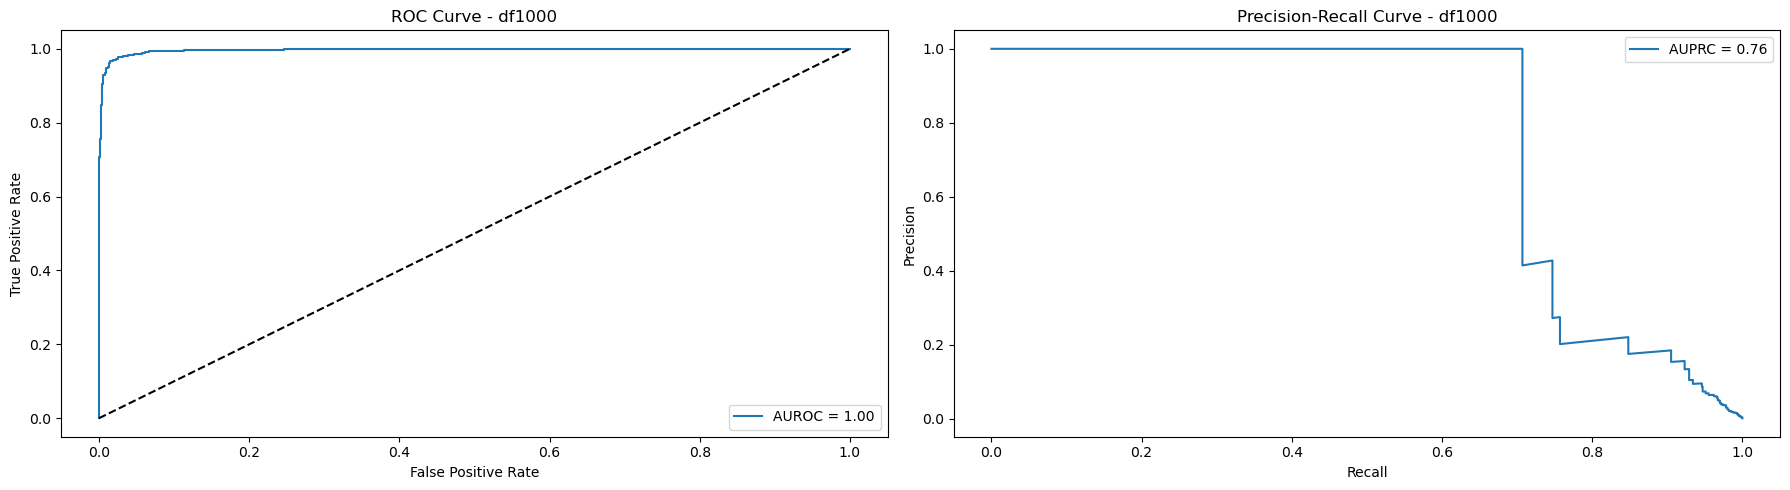

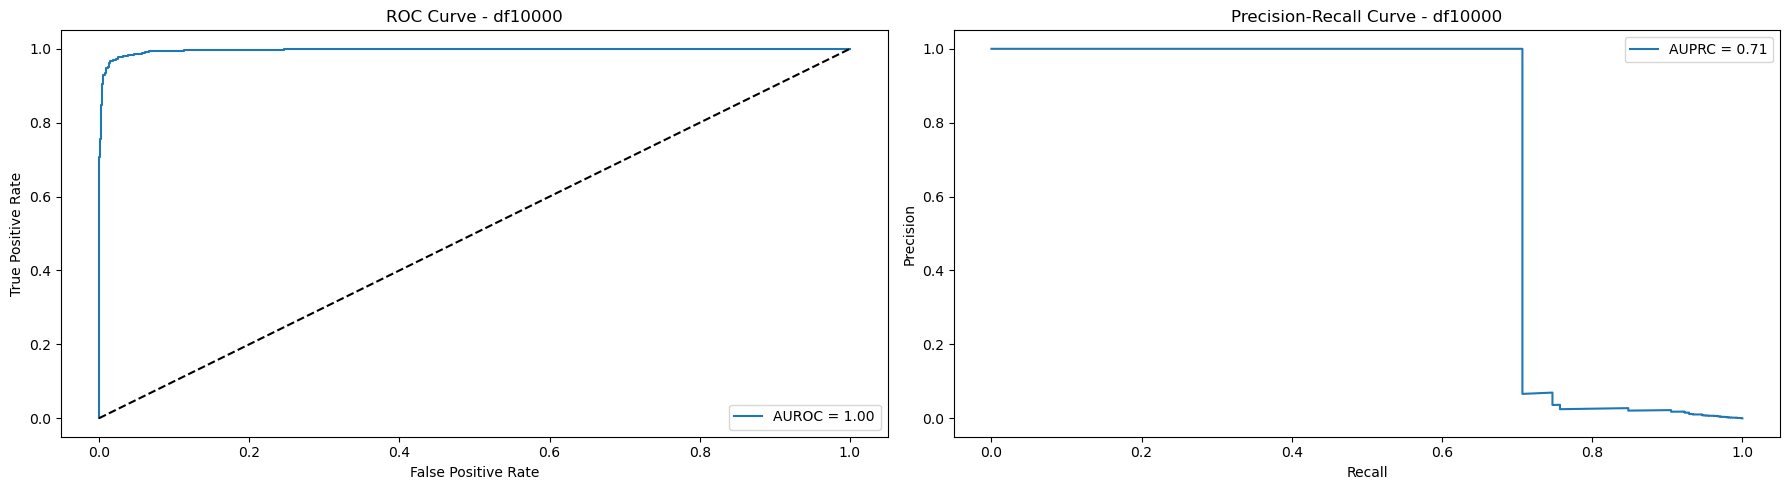

In [7]:
def plot_roc_pr_prgain(df, target_class, class1, class2, feature1, feature2, title):
    df_selected = df[(df['target'] == class1) | (df['target'] == class2)]
    X = df_selected[[feature1, feature2]].values
    y = df_selected['target'].values

    y_binary = np.where(y == target_class, 0, 1)

    lda = LinearDiscriminantAnalysis()
    y_scores = lda.fit(X, y_binary).decision_function(X)
    
    fpr, tpr, _ = roc_curve(y_binary, y_scores)
    auroc = auc(fpr, tpr)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'AUROC = {auroc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}')
    plt.legend()

    precision, recall, _ = precision_recall_curve(y_binary, y_scores)
    auprc = auc(recall, precision)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f'AUPRC = {auprc:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {title}')
    plt.legend()


    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_roc_pr_prgain(df, 0, class1, class2, feature1, feature2, title=name)


[8] В пункте [7] выбрать другой целевой класс.
- Построить ROC кривую и рассчитать метрику AUROC.
- Построить PR кривую и рассчитать метрику AUPRC.
- (*) Построить PRgain кривую и рассчитать метрику AUPRgainC.

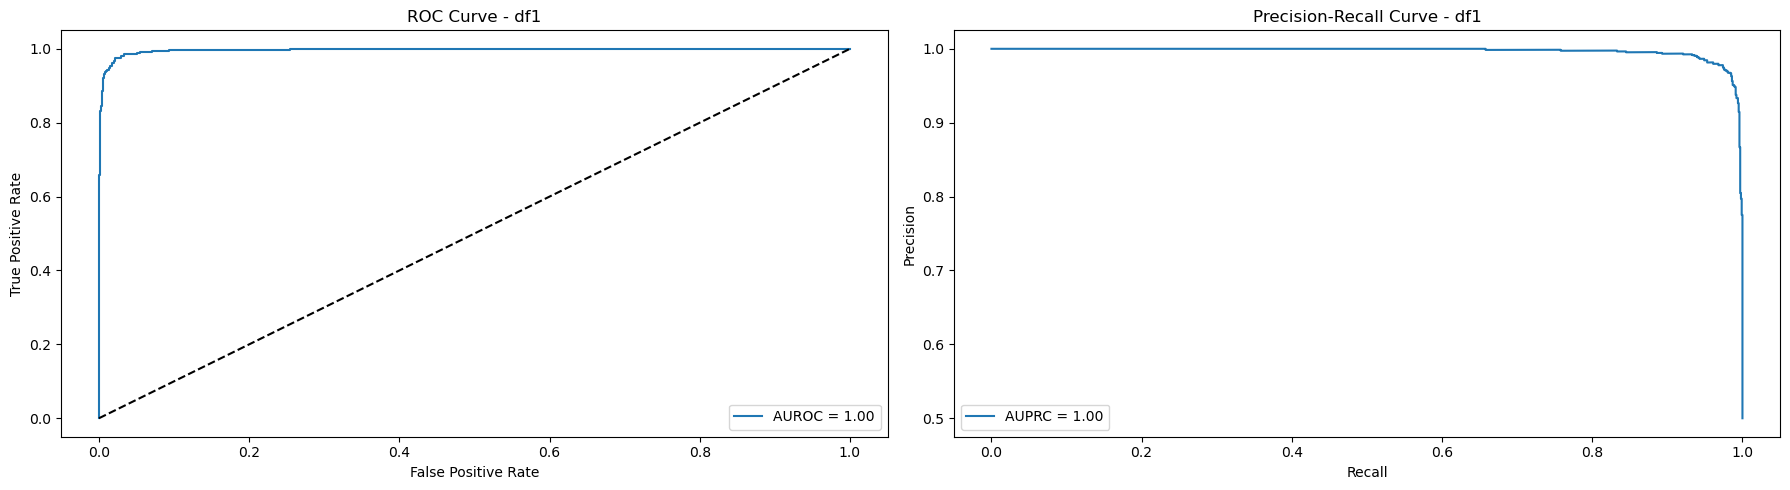

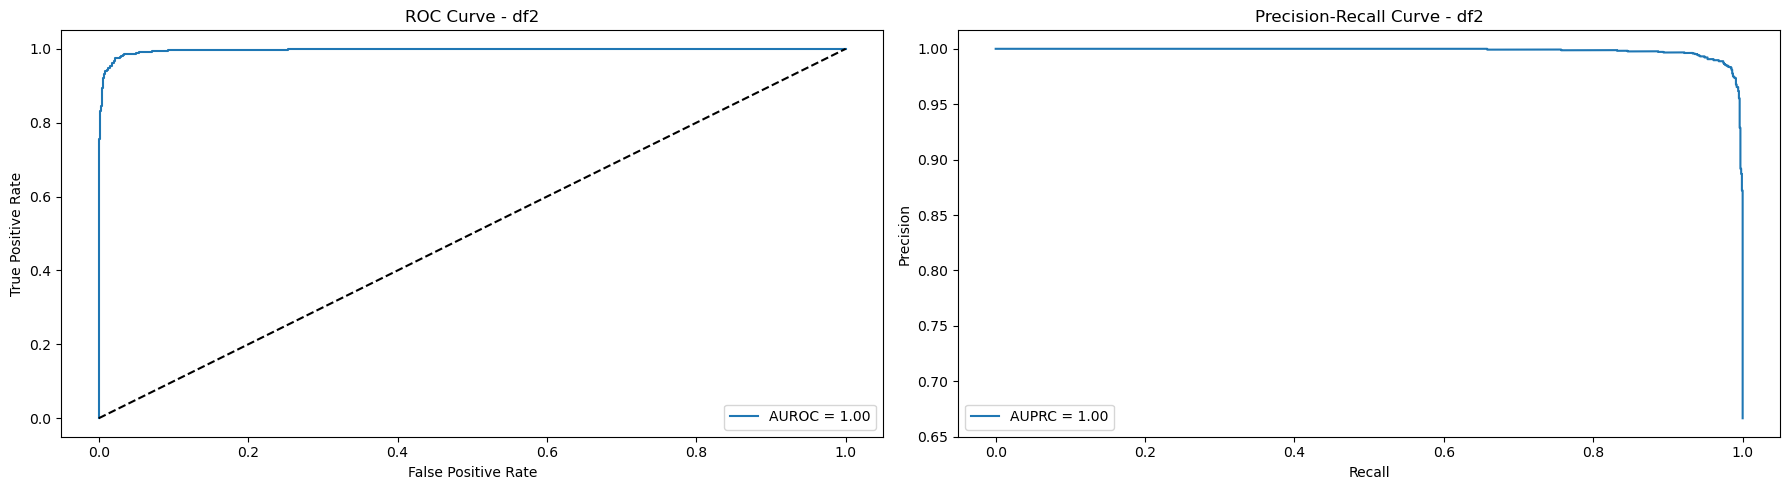

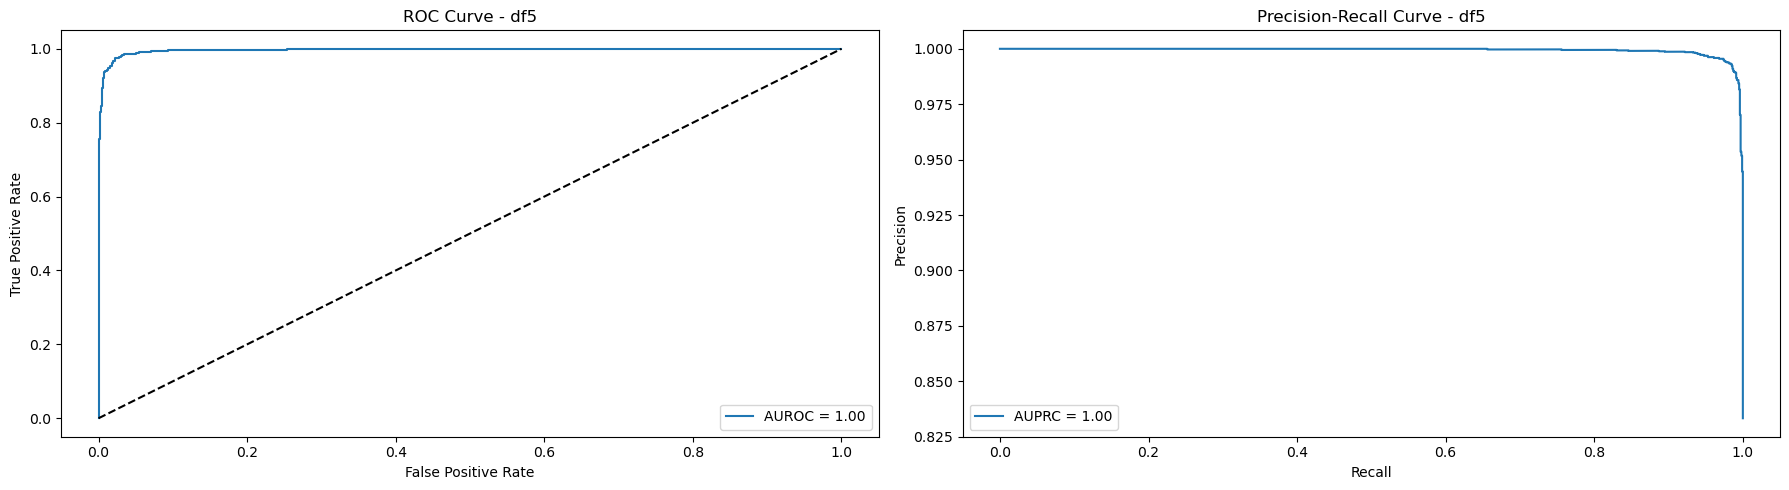

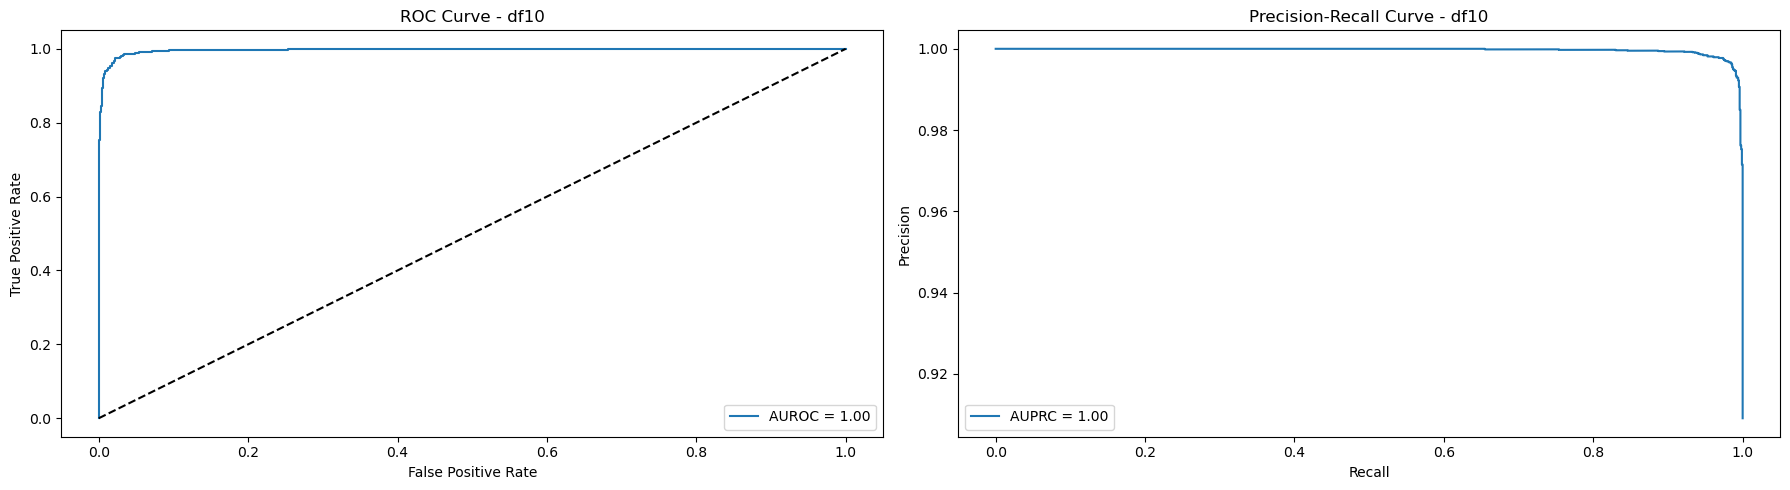

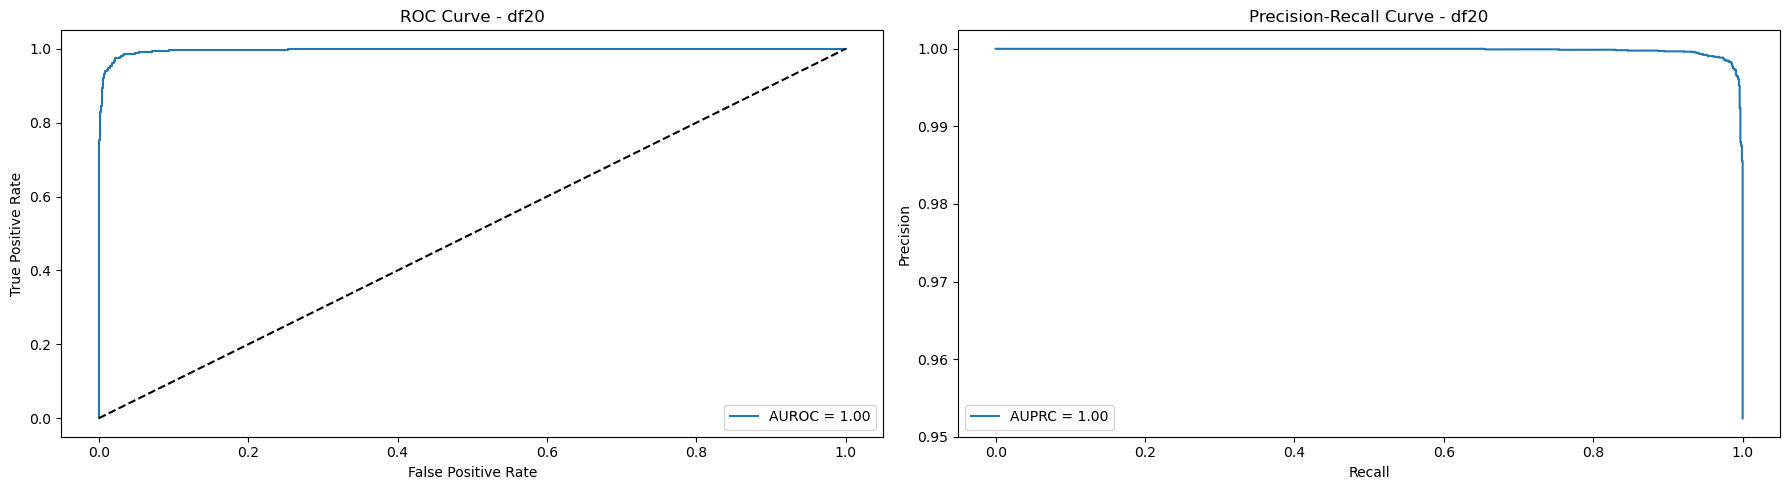

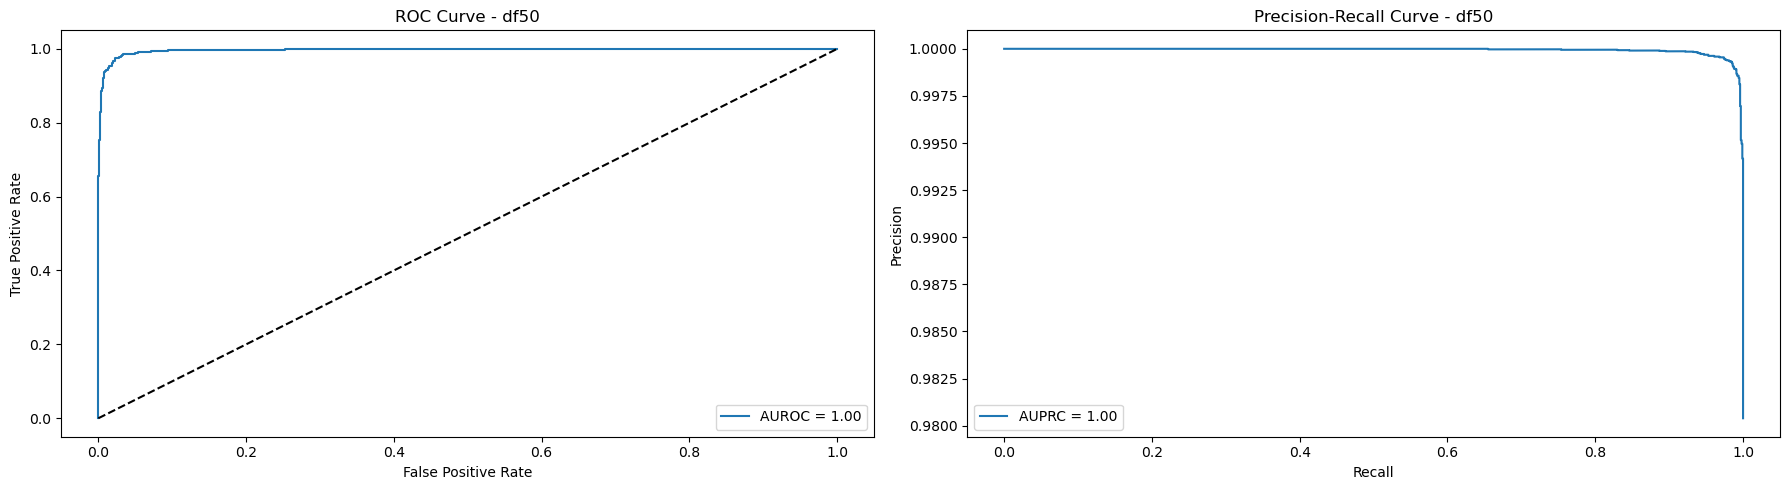

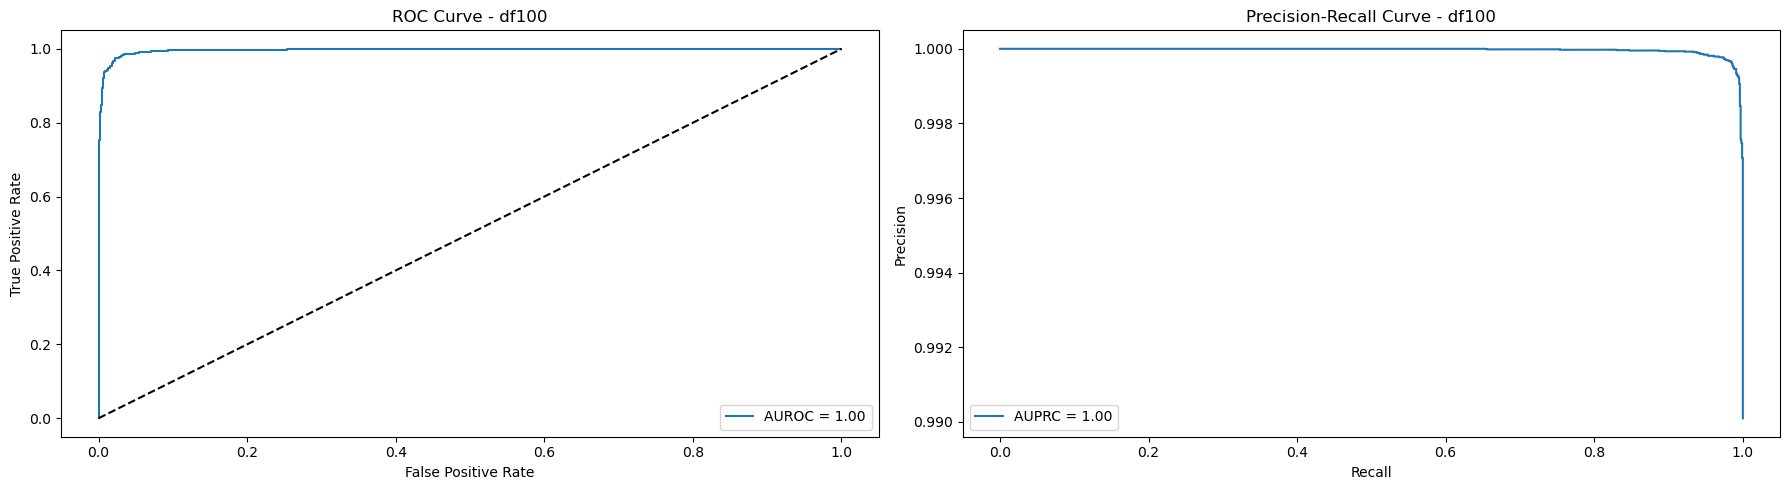

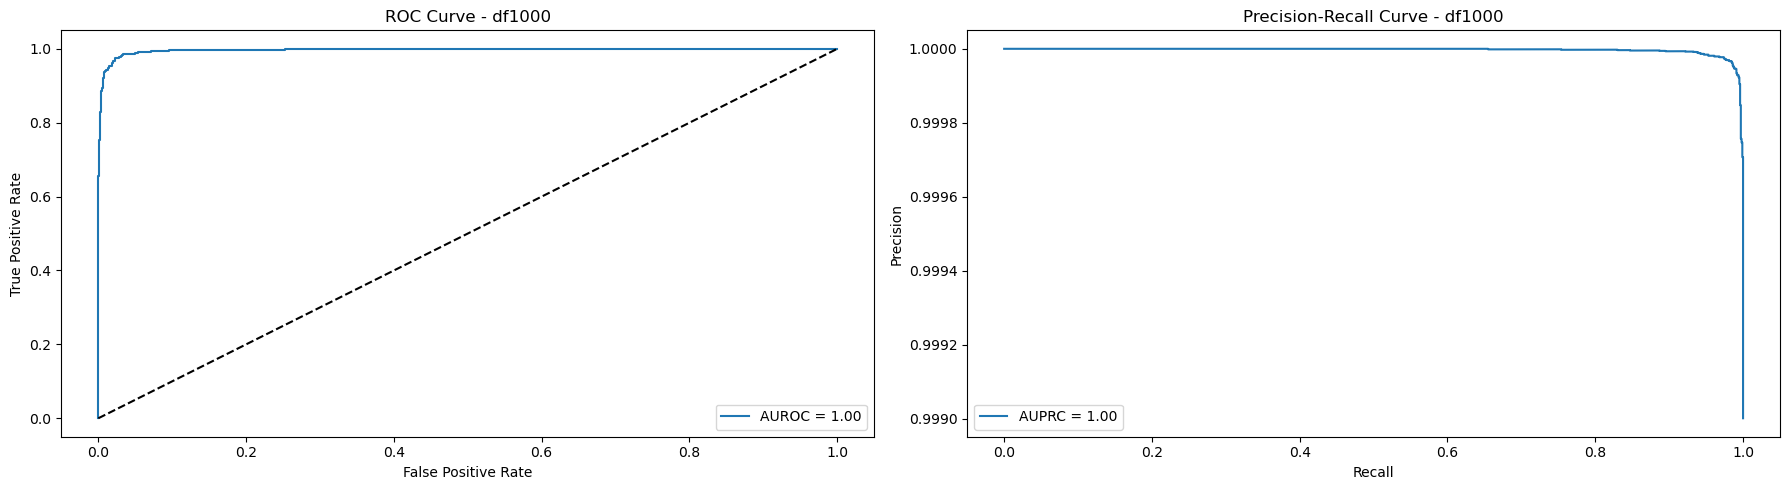

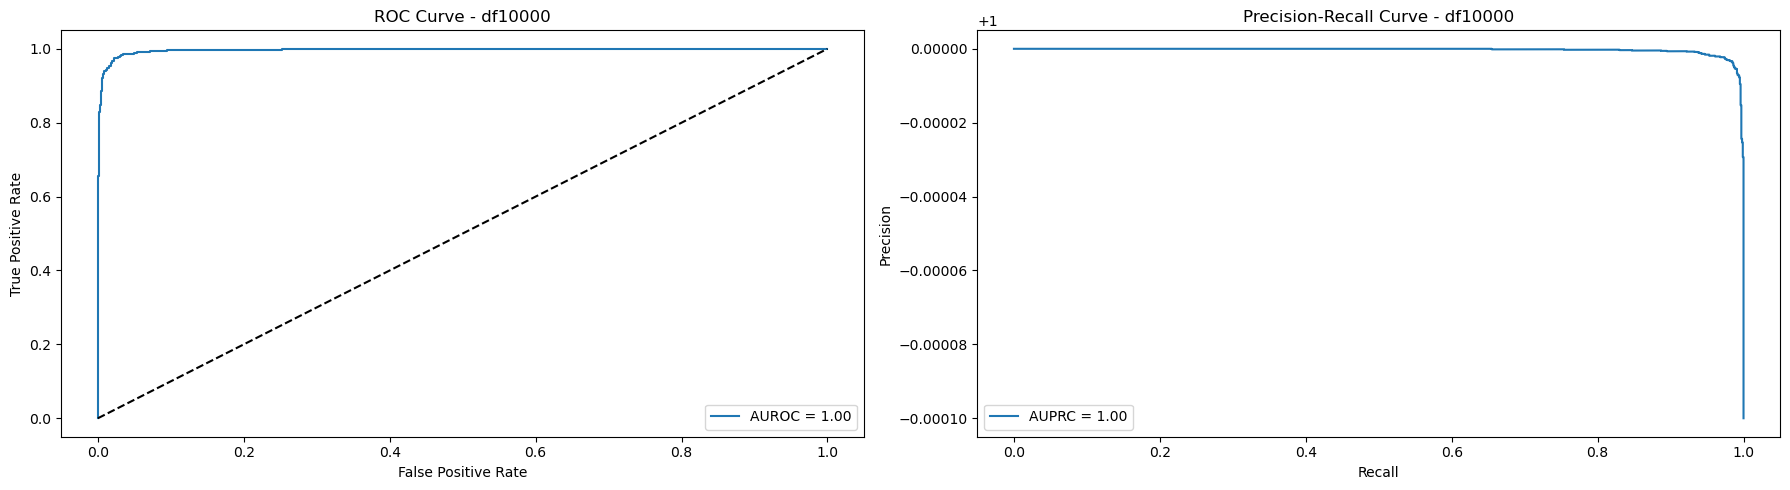

In [8]:
for name, df in datasets.items():
    plot_roc_pr_prgain(df, 1, class1, class2, feature1, feature2, title=name)

[9] Для датасета 10k на основе 3-fold, 5-fold, 10-fold, 20-fold, 50-fold, 100-fold кросс-
валидации построить кривые AUROC и AUPRC c доверительными интервалами
(CI95). Вместо CI95 можно взять CI90, CI80 или другой вариант доверительного
интервала.

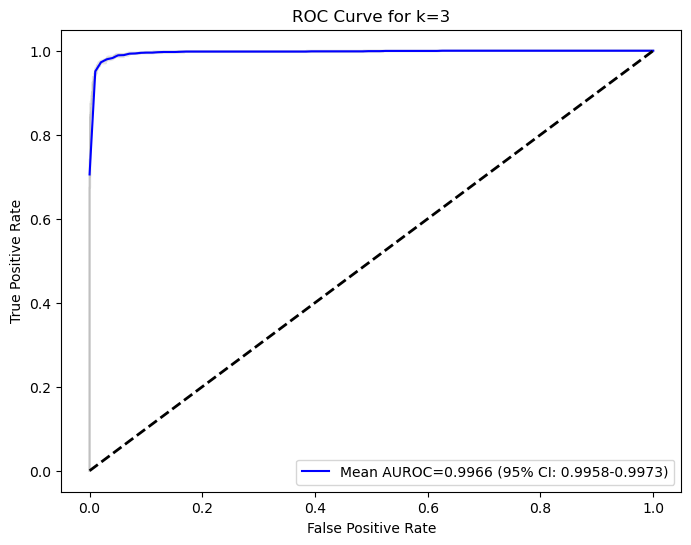

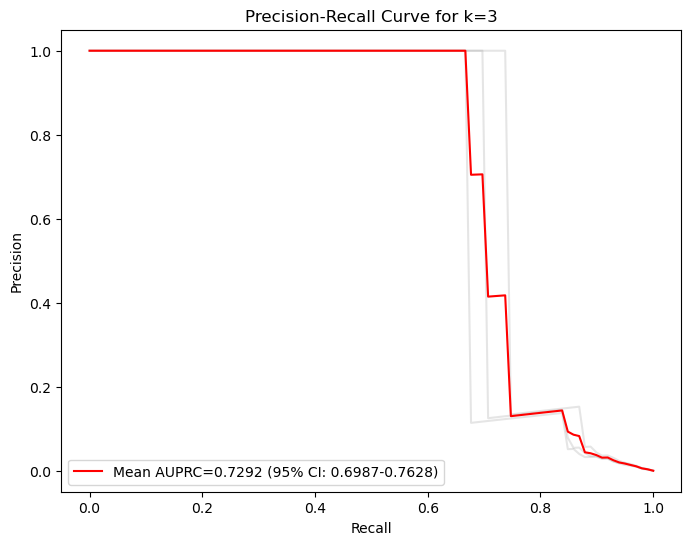

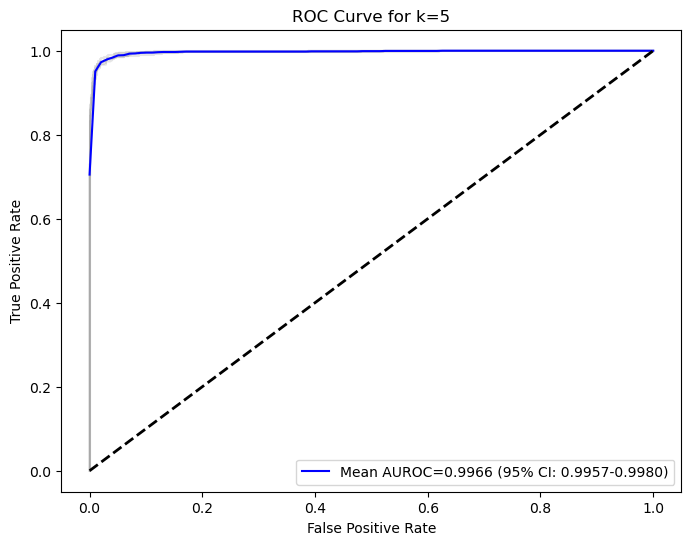

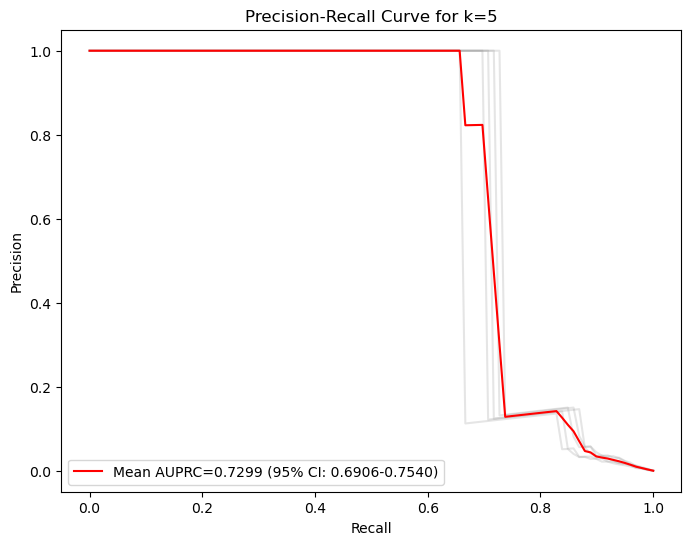

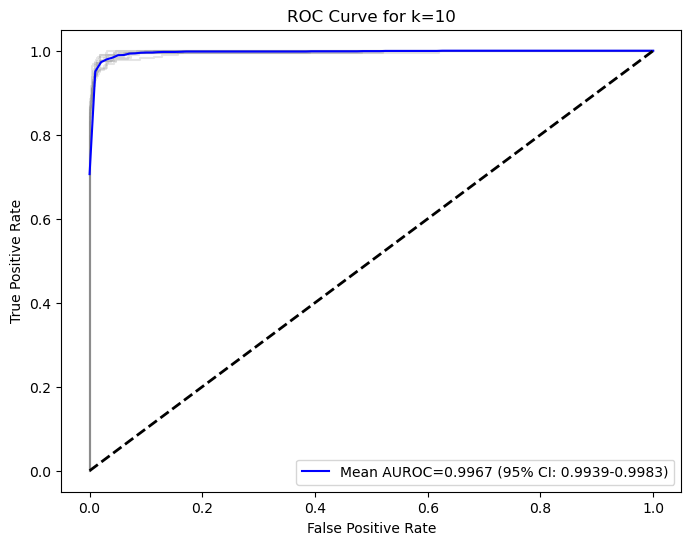

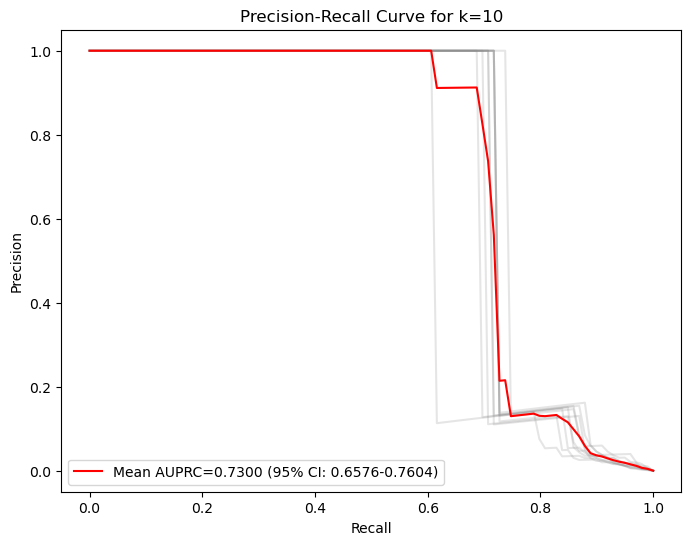

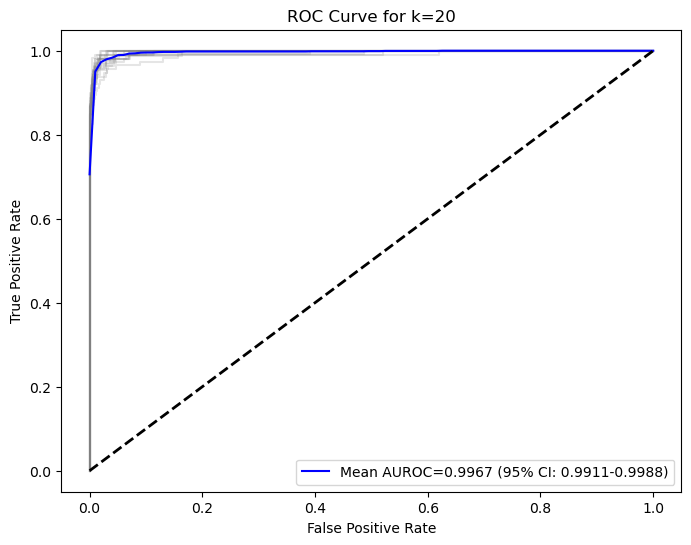

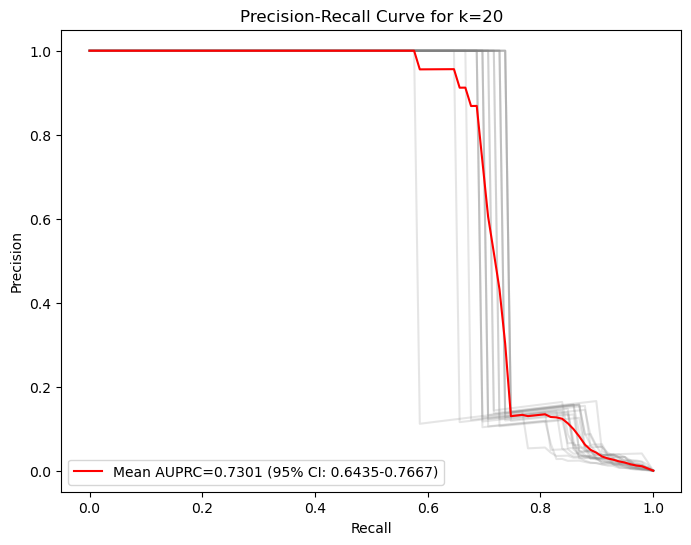

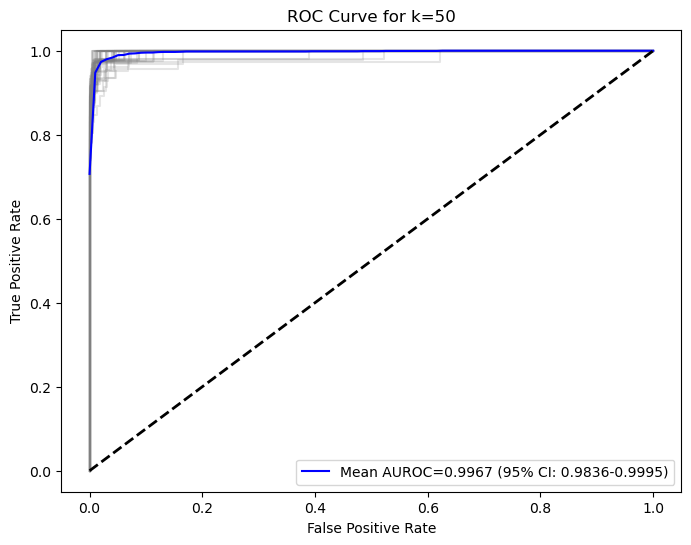

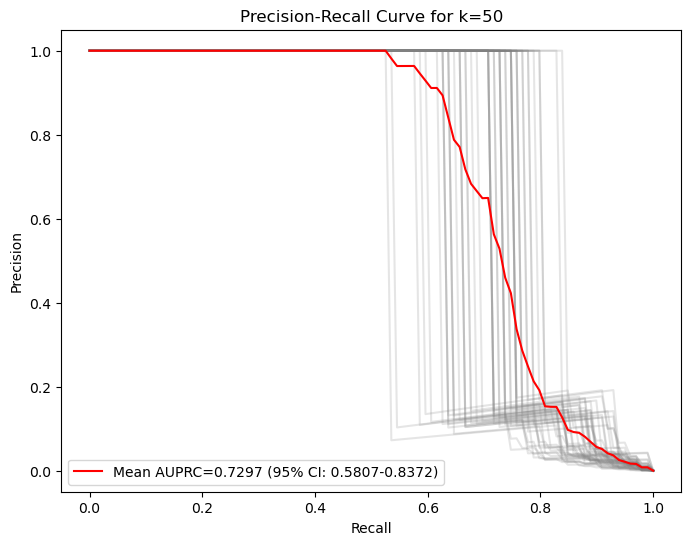

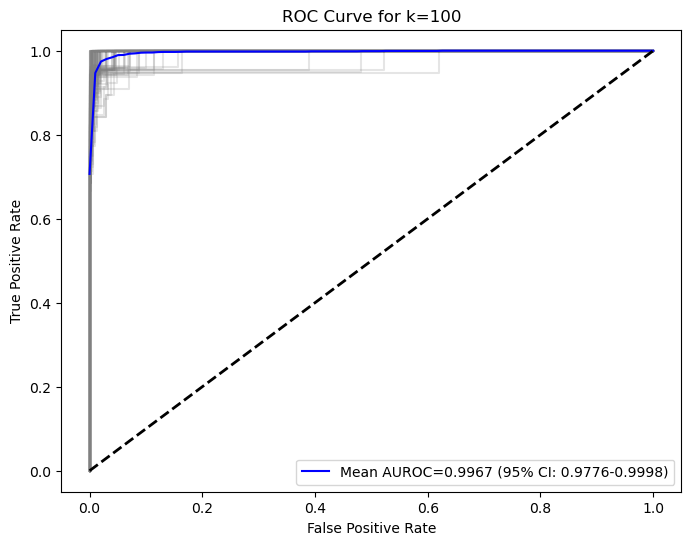

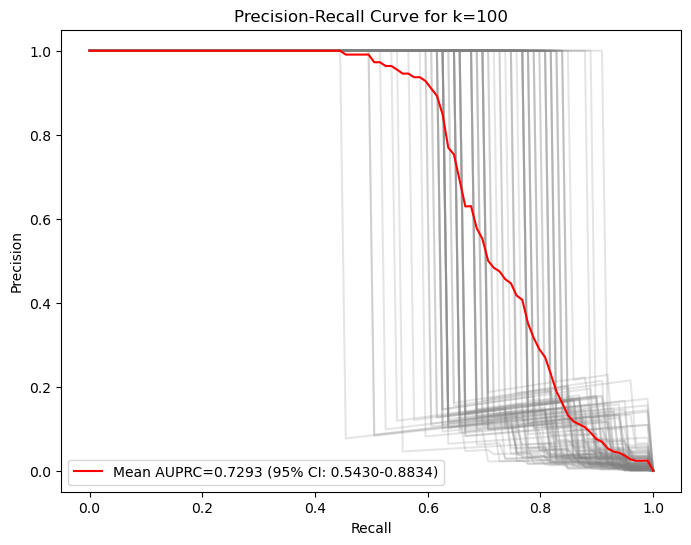

In [ ]:
def plot_cv_curves(X, y, k_values):
    recall_array = np.linspace(0, 1, 100)
    
    for k in k_values:
        k_fold = KFold(n_splits=k, shuffle=True, random_state=10)
        predictor = LinearDiscriminantAnalysis()

        fpr_all, tpr_all, auc_roc_all_fold = [], [], []
        precision_fold_all, recall_fold_all = [], []
        
        for i, (train_index, test_index) in enumerate(k_fold.split(X)):
            Xtrain, Xtest = X[train_index], X[test_index]
            ytrain, ytest = y[train_index], y[test_index]

            predictor.fit(Xtrain, ytrain)
            pred_proba = predictor.predict_proba(Xtest)

            fpr, tpr, _ = roc_curve(ytest, pred_proba[:, 1])
            auc_roc = auc(fpr, tpr)
            fpr_all.append(fpr)
            tpr_all.append(tpr)
            auc_roc_all_fold.append(auc_roc)

            precision_fold, recall_fold, _ = precision_recall_curve(ytest, pred_proba[:, 1])
            precision_fold, recall_fold = precision_fold[::-1], recall_fold[::-1]

            precision_fold_all.append(np.interp(recall_array, recall_fold, precision_fold))

        mean_fpr = np.linspace(0, 1, 100)
        mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(fpr_all, tpr_all)], axis=0)
        mean_auc_roc = np.mean(auc_roc_all_fold)
        std_auc_roc = np.std(auc_roc_all_fold)
        lower_auc_roc = np.percentile(auc_roc_all_fold, 2.5)
        upper_auc_roc = np.percentile(auc_roc_all_fold, 97.5)

        plt.figure(figsize=(8, 6))
        for fpr, tpr in zip(fpr_all, tpr_all):
            plt.plot(fpr, tpr, color='grey', alpha=0.2)
        plt.plot(mean_fpr, mean_tpr, color='blue', label=f'Mean AUROC={mean_auc_roc:.4f} (95% CI: {lower_auc_roc:.4f}-{upper_auc_roc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for k={k}')
        plt.legend(loc='lower right')
        plt.show()

        mean_precision = np.mean(precision_fold_all, axis=0)
        mean_recall = recall_array
        mean_auc_pr = auc(mean_recall, mean_precision)
        std_auc_pr = np.std([auc(recall_array, precision) for precision in precision_fold_all])
        lower_auc_pr = np.percentile([auc(recall_array, precision) for precision in precision_fold_all], 2.5)
        upper_auc_pr = np.percentile([auc(recall_array, precision) for precision in precision_fold_all], 97.5)

        plt.figure(figsize=(8, 6))
        for precision in precision_fold_all:
            plt.plot(recall_array, precision, color='grey', alpha=0.2)
        plt.plot(mean_recall, mean_precision, color='red', label=f'Mean AUPRC={mean_auc_pr:.4f} (95% CI: {lower_auc_pr:.4f}-{upper_auc_pr:.4f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve for k={k}')
        plt.legend(loc='lower left')
        plt.show()

plot_cv_curves(X=X, y=y, k_values=[3, 5, 10, 20, 50, 100])
